# LeetCode #189: Rotate Array

https://leetcode.com/problems/rotate-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \cdot k)$ | $O(1)$ |
| **Extra Array** | $O(n)$ | $O(n)$ |
| **Three Reversals** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Rotate one step at a time: save the last element, shift every element one position right, place the saved element at index 0. Repeat k times. $O(n \cdot k)$ total moves — degenerate when k $\approx$ n.

### Extra Array
Copy each element to its destination index $(i + k) \bmod n$ in a second array, then copy back. Linear time but wastes $O(n)$ auxiliary space equal to the input size.

### Optimal: Three Reversals ★
Normalize k = k % n, then:
1. Reverse the entire array.
2. Reverse the first k elements.
3. Reverse the remaining n − k elements.

The three reversals together permute every element to its rotated destination.

**Why this is better than Extra Array:** Achieves the same $O(n)$ time with $O(1)$ space — the reversal trick performs all moves in-place using only a swap variable.

**Constraints:**
* 1 ≤ nums.length ≤ 10⁵
* −2³¹ ≤ nums[i] ≤ 2³¹ − 1
* 0 ≤ k ≤ 10⁵

## Solutions

### C#

In [ ]:
public class Solution {
    public void Rotate(int[] nums, int k) {
        k %= nums.Length;
        Reverse(nums, 0, nums.Length - 1);
        Reverse(nums, 0, k - 1);
        Reverse(nums, k, nums.Length - 1);
    }

    private void Reverse(int[] nums, int lo, int hi) {
        while (lo < hi) {
            (nums[lo], nums[hi]) = (nums[hi], nums[lo]);
            lo++; hi--;
        }
    }
}

### Python

In [ ]:
class Solution:
    def rotate(self, nums: List[int], k: int) -> None:
        def reverse(lo: int, hi: int) -> None:
            while lo < hi:
                nums[lo], nums[hi] = nums[hi], nums[lo]
                lo += 1; hi -= 1
        k %= len(nums)
        reverse(0, len(nums) - 1)
        reverse(0, k - 1)
        reverse(k, len(nums) - 1)

### Go

In [ ]:
func rotate(nums []int, k int) {
    reverse := func(lo, hi int) {
        for lo < hi {
            nums[lo], nums[hi] = nums[hi], nums[lo]
            lo++; hi--
        }
    }
    k %= len(nums)
    reverse(0, len(nums)-1)
    reverse(0, k-1)
    reverse(k, len(nums)-1)
}

### Rust

In [ ]:
pub fn rotate(nums: &mut Vec<i32>, k: i32) {
    let n = nums.len();
    let k = k as usize % n;
    nums.reverse();
    nums[..k].reverse();
    nums[k..].reverse();
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 2, 3, 4, 5, 6, 7], k = 3
Step 1 — reverse all: [7, 6, 5, 4, 3, 2, 1]. Step 2 — reverse first 3: [5, 6, 7, 4, 3, 2, 1]. Step 3 — reverse last 4: [5, 6, 7, 1, 2, 3, 4]. Result: **[5, 6, 7, 1, 2, 3, 4]** — elements 5, 6, 7 (the last k) wrap to the front.

**2. Slightly Complex — k larger than n (k = 10, n = 7)**
**Input:** nums = [1, 2, 3, 4, 5, 6, 7], k = 10
k % 7 = 3. After normalization, this reduces to the same three-step process as k=3. A full rotation (k=7) returns the array to itself — rotating by 10 is identical to rotating by 3. Normalizing first prevents two redundant full passes through the array that Brute Force would perform.

**3. Edge Case: Time Factor — k = n (full rotation, net no-op)**
**Input:** nums = [1, 2, 3, 4, 5], k = 5
k % 5 = 0. Step 1: reverse all → [5,4,3,2,1]. Step 2: reverse(0, −1) → lo > hi, zero swaps. Step 3: reverse(0, 4) → [1,2,3,4,5]. Net result: original array. Brute Force would perform n × k = 25 element moves; Three Reversals performs $\approx n$ swaps total regardless of k. The third reverse undoes the first, costing 2n/2 swaps but still $O(n)$.

**4. Edge Case: Space Factor — n = 10⁵, k = 1**
**Input:** nums = [extremely long array], k = 1
Extra Array allocates 10⁵ integers ($\approx$ 400 KB for int32). Three Reversals uses exactly two integer variables for the swap regardless of n. For k=1 specifically: reverse all (n/2 swaps), reverse first 1 (0 swaps), reverse last n−1 ((n−2)/2 swaps) → O(n) swaps, O(1) space.

**5. Almost-Impossible but Plausible — single element**
**Input:** nums = [42], k = 99
k % 1 = 0. reverse(0, 0): lo == hi, zero swaps. reverse(0, −1): lo > hi, zero swaps. reverse(0, 0): zero swaps. Returns [42]. All three reversal calls are no-ops — the single-element case is handled without any special guard.

## Infographic

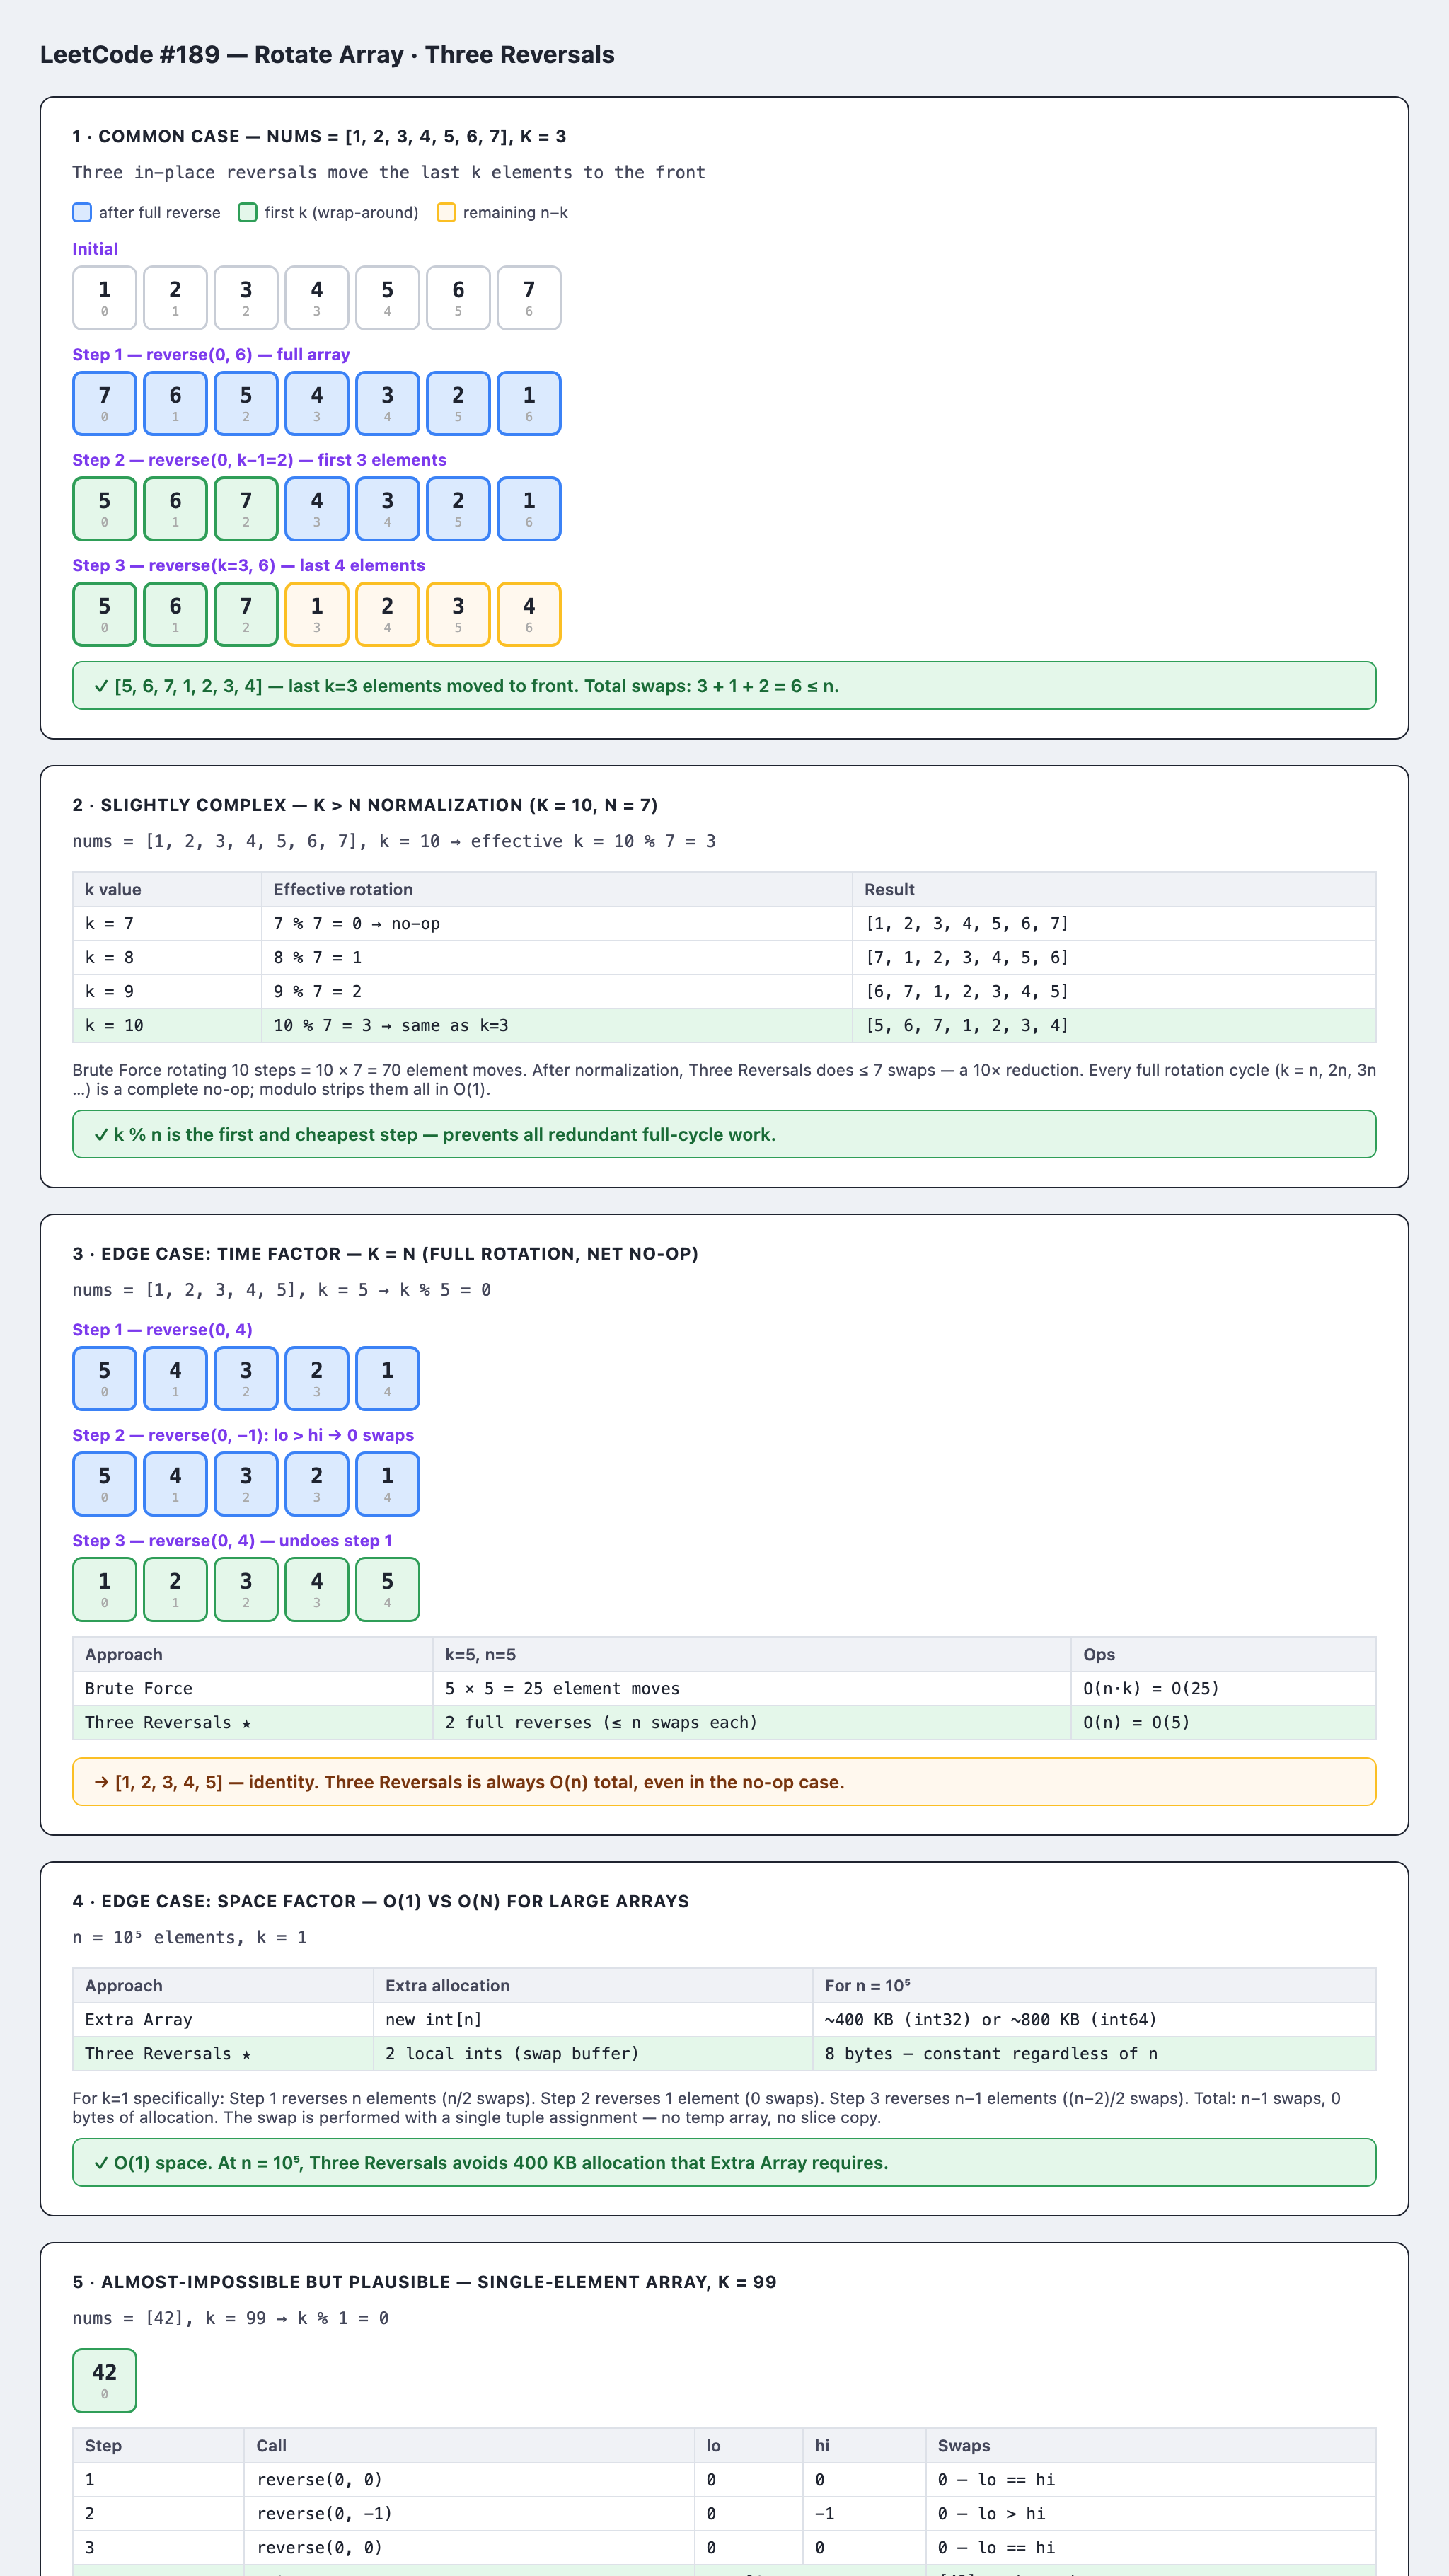